1 overview

This notebook analyzes clinical and demographic characterestics of patient with THC(Thyroid Hydatid Cyst)

The objectives are:

1-1- perform exploratoy data analysis

1-2- describe continuous and binary variables

1-3- evaluate associatons between clinical factors and cyst size

1-4- apply non-parametric statiscal tests(Mann-Whitney-tests)

1-5- explore correlations between variables


2 loading libraries and data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import spearmanr
from scipy.stats import kruskal
np.random.seed(42)
plt.style.use('default')

In [2]:
df=pd.read_csv('thyroid_hydatid_cyst_cleaned.csv')


In [3]:
print(df.info())
print('---------------------------')
print(df.head())
print('---------------------------')
print(df.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75 entries, 0 to 74
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   patient_id         75 non-null     int64  
 1   year               75 non-null     int64  
 2   rural              33 non-null     float64
 3   gender             74 non-null     float64
 4   age                74 non-null     float64
 5   country            75 non-null     object 
 6   duration_years     37 non-null     float64
 7   cyst_size_mm       36 non-null     float64
 8   Serology           31 non-null     float64
 9   follow_up_outcome  39 non-null     float64
 10  medication         74 non-null     float64
 11  surgery            74 non-null     float64
 12  right_lobe         73 non-null     float64
 13  left_lobe          73 non-null     float64
 14  has_mass           73 non-null     float64
 15  has_pulmonary      73 non-null     float64
 16  has_digestive      73 non-nu

3 descriptive statistics and EDA

3.1 continuous data

In [4]:
columns=['age','cyst_size_mm','duration_years']

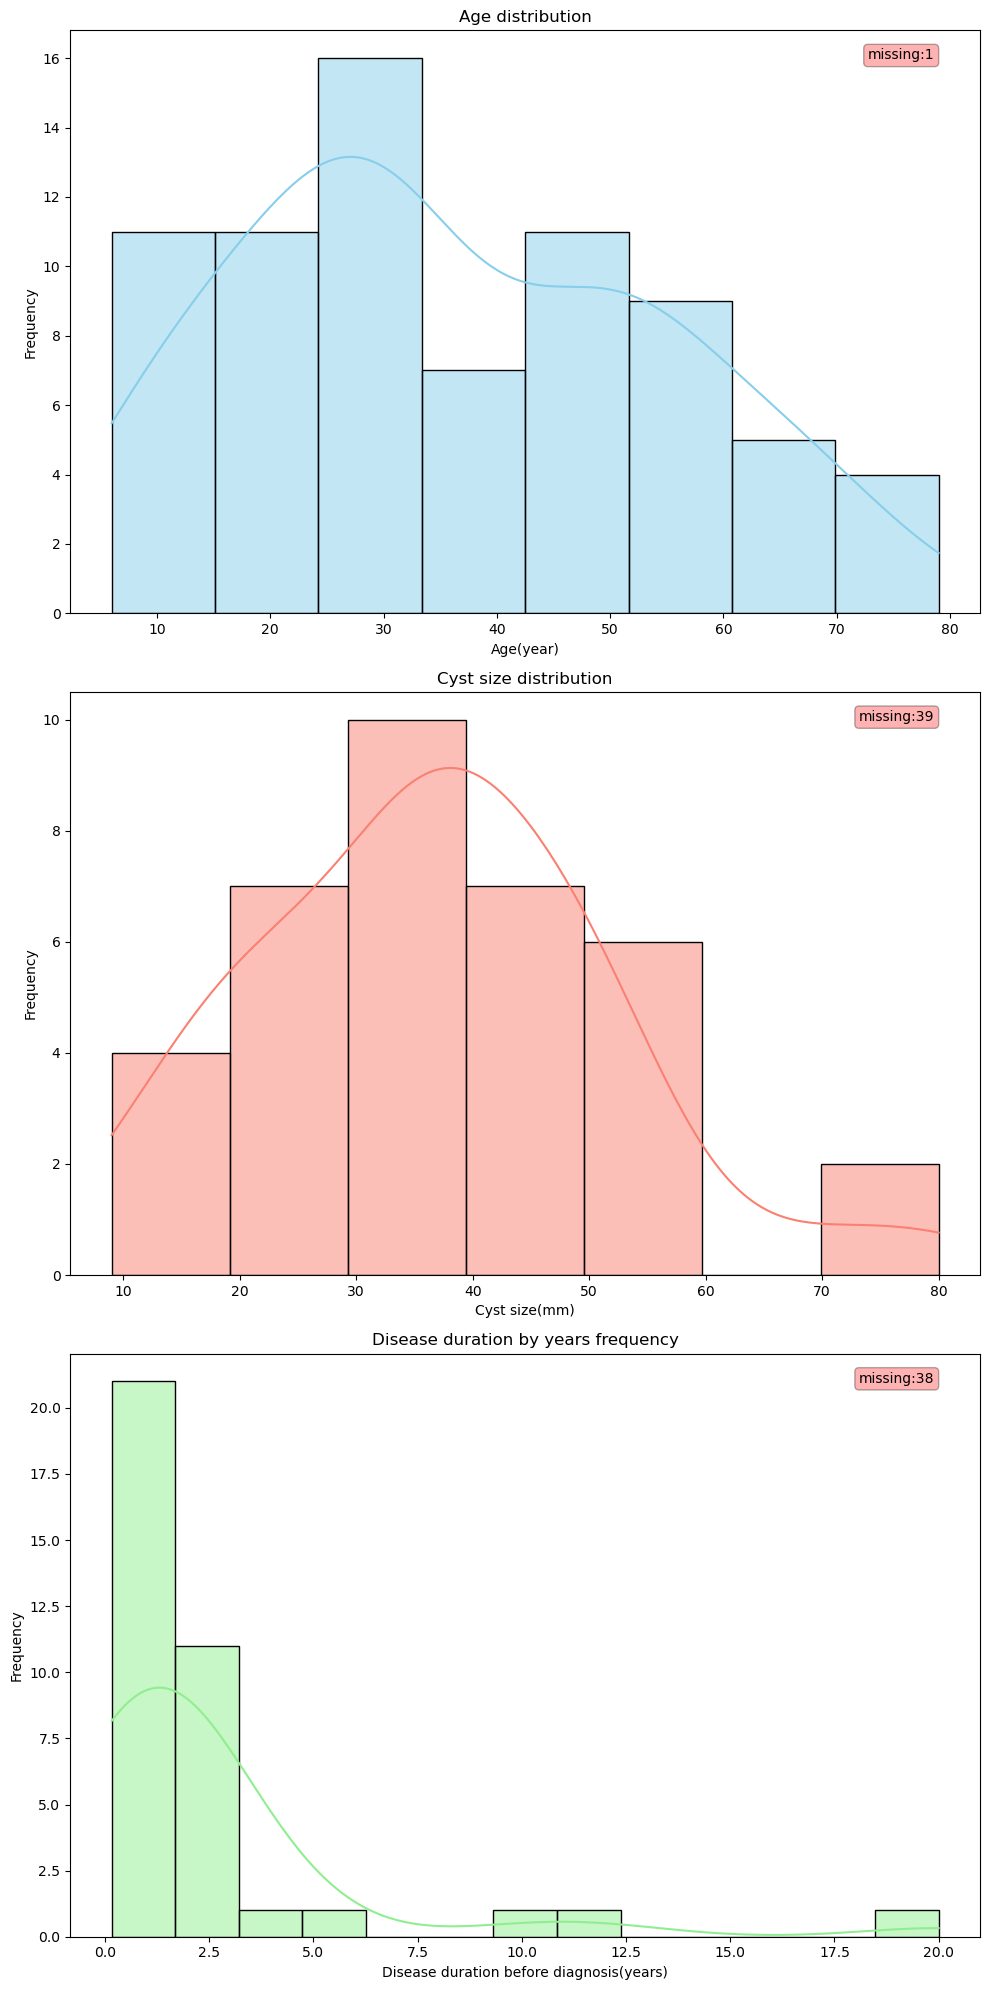

In [5]:
#We visualize distribution of continuous variables to assess normality.
fig,axes=plt.subplots(3,1,figsize=(10,20))
sns.histplot(data=df,x=columns[0],kde=True,ax=axes[0],color='skyblue')
axes[0].set_xlabel('Age(year)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Age distribution')
sns.histplot(data=df,x=columns[1],kde=True,ax=axes[1],color='salmon')
axes[1].set_xlabel('Cyst size(mm)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Cyst size distribution')
sns.histplot(data=df,x=columns[2],kde=True,ax=axes[2],color='lightgreen')
axes[2].set_xlabel('Disease duration before diagnosis(years)')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Disease duration by years frequency')
for i,col in enumerate(columns):
    axes[i].text(0.95,0.95,f'missing:{df[col].isna().sum()}',transform=axes[i].transAxes,
                bbox=dict(boxstyle='round',facecolor='red',alpha=0.3),ha='right',fontsize=10)
plt.tight_layout()
plt.show()

In [6]:
#calculate skewness of data
for col in columns:
    print(f'skewness of {col} = {df[col].skew()}')
#our data are positively skewed

skewness of age = 0.3084441975830513
skewness of cyst_size_mm = 0.5506455768902454
skewness of duration_years = 3.3356433524581037


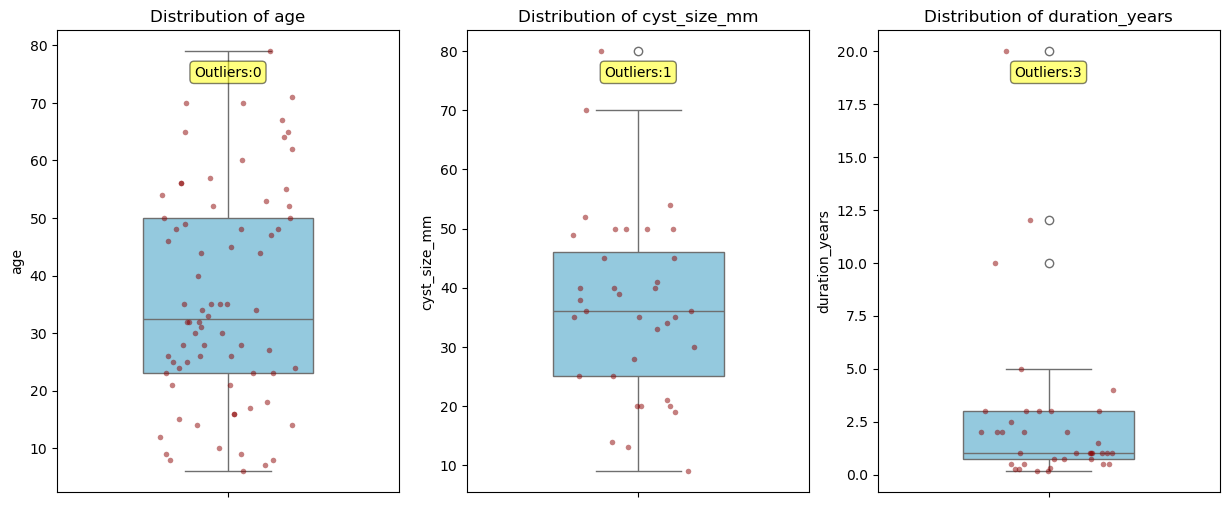

In [7]:
fig,axes=plt.subplots(1,3,figsize=(15,6))
for i,col in enumerate(columns):
    sns.boxplot(data=df,y=col,ax=axes[i],color='skyblue',width=0.5)
    sns.stripplot(data=df,y=col,ax=axes[i],color='darkred',size=4,alpha=0.5,jitter=0.2)
    axes[i].set_title(f'Distribution of {col}')
    Q1=df[col].quantile(0.25)
    Q3=df[col].quantile(0.75)
    IQR=Q3-Q1
    outliers=df[(df[col]<Q1-1.5*IQR)|(df[col]>Q3+1.5*IQR)]
    axes[i].text(0.5,0.9,f'Outliers:{len(outliers)}',
    transform=axes[i].transAxes,
    bbox=dict(boxstyle='round',facecolor='yellow',alpha=0.5),ha='center')

In [8]:
data={}
for i,col in enumerate(columns):
    list_num=[]
    list_num.append([df[col].mean(),df[col].min(),df[col].max(),df[col].median(),df[col].isna().sum()])
    data[i]=list_num
data

{0: [[np.float64(36.108108108108105),
   np.float64(6.0),
   np.float64(79.0),
   np.float64(32.5),
   np.int64(1)]],
 1: [[np.float64(36.69444444444444),
   np.float64(9.0),
   np.float64(80.0),
   np.float64(36.0),
   np.int64(39)]],
 2: [[np.float64(2.5243243243243243),
   np.float64(0.16),
   np.float64(20.0),
   np.float64(1.0),
   np.int64(38)]]}

In [9]:
df_num=pd.DataFrame({'age':data[0][0],'cyst_size':data[1][0],'duration_year':data[2][0]},
                   index=['mean','min','max','median','NaN number']).T

In [10]:
df_num.to_csv('continuous_variables_summary.csv')

In [11]:
a=df[['age','cyst_size_mm']].dropna().reset_index(drop=True)
r,p=spearmanr(a['age'],a['cyst_size_mm'])
print(f'spearman correlation: r={r:.3f}  p={p:.3f}')
#no significant correlation between age and cyst size

spearman correlation: r=-0.117  p=0.505


Text(0.5, 1.0, 'Relationship between Age and Thyroid Cyst Size')

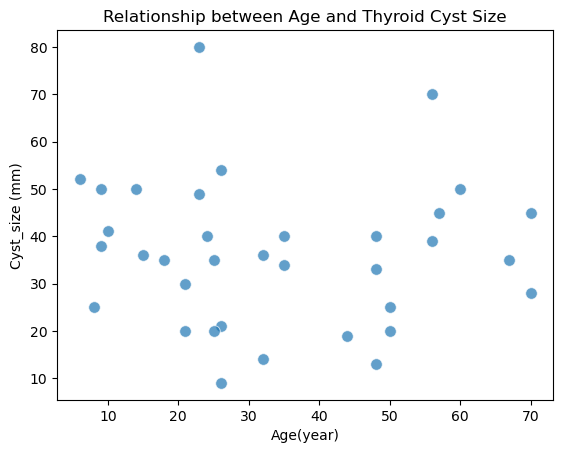

In [12]:
#age to thyroid cyst size relation
sns.scatterplot(data=a,x='age',y='cyst_size_mm',s=70,alpha=0.7)
plt.xlabel('Age(year)')
plt.ylabel('Cyst_size (mm)')
plt.title("Relationship between Age and Thyroid Cyst Size")

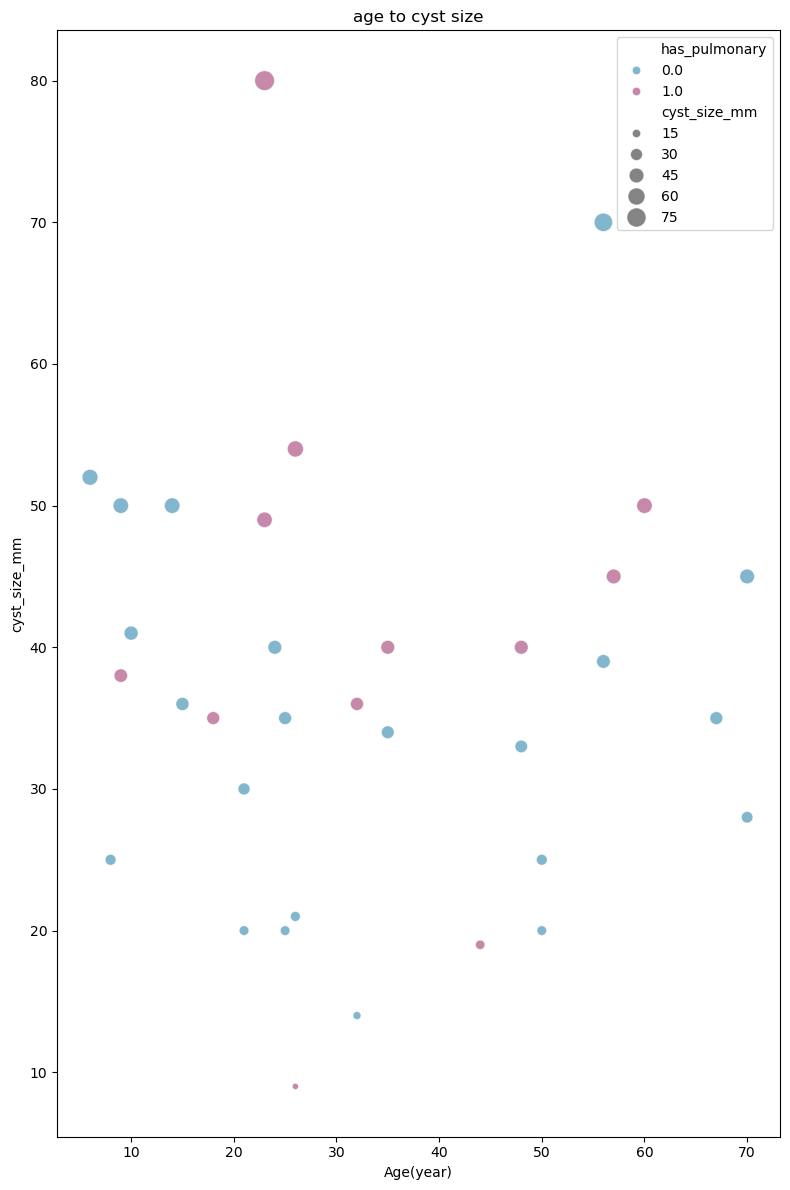

In [13]:
fig,axes=plt.subplots(figsize=(8,12))
sns.scatterplot(data=df,x='age',y='cyst_size_mm',size='cyst_size_mm',hue='has_pulmonary',
               sizes=(20,200),alpha=0.6,palette=['#2E86AB', '#A23B72'])
axes.set_xlabel('Age(year)')
axes.set_ylabel('cyst_size_mm')
axes.set_title('age to cyst size')
axes.legend()
plt.tight_layout()
plt.show()

3.2 binary data

In [14]:
#cyst size of patients who received medication  and the size of thyroid cyst was reported
med_yes=df['cyst_size_mm'][df['medication']==1].dropna()
#cyst size of patients who hasn't received medication  and the size of thyroid cyst was reported
med_no=df['cyst_size_mm'][df['medication']==0].dropna()
#cyst size of patients who has pulmonary cyst and the size of thyroid cyst was reported
pulmonary_yes=df['cyst_size_mm'][df['has_pulmonary']==1].dropna()
#cyst size of patients who hasn't pulmonary cyst and the size of thyroid cyst was reported
pulmonary_no=df['cyst_size_mm'][df['has_pulmonary']==0].dropna()
#cyst size of patients who has  only right lobe involvement and the size of thyroid cyst was reported
just_left_lobe=df['cyst_size_mm'][df["right_lobe"]==0].dropna().reset_index(drop=True)
#cyst size of patients who has  only left lobe involvement and the size of thyroid cyst was reported
just_right_lobe=df['cyst_size_mm'][df['left_lobe']==0].dropna().reset_index(drop=True)
#cyst size of patients who has   left and right lobe involvement and the size of thyroid cyst was reported
both_lobe=df['cyst_size_mm'][(df['right_lobe']==1) & (df['left_lobe']==1)].dropna().reset_index(drop=True)
#dicriptive table
summary_data={'cyst_size_mm_median':[med_yes.median(),med_no.median(),pulmonary_yes.median()
,pulmonary_no.median(),just_right_lobe.median(),just_left_lobe.median(),both_lobe.median()],
'number':[len(med_yes),len(med_no),len(pulmonary_yes),
         len(pulmonary_no),len(just_right_lobe),len(just_left_lobe),len(both_lobe)] }
index=['medication_yes','medication_no','pulmonary_yes','pulmonary_no',
       'lobar_right','lobar_left','both_lobe']
df1=pd.DataFrame(summary_data,index=index)
df1.to_csv('binary_variables_summary.csv')



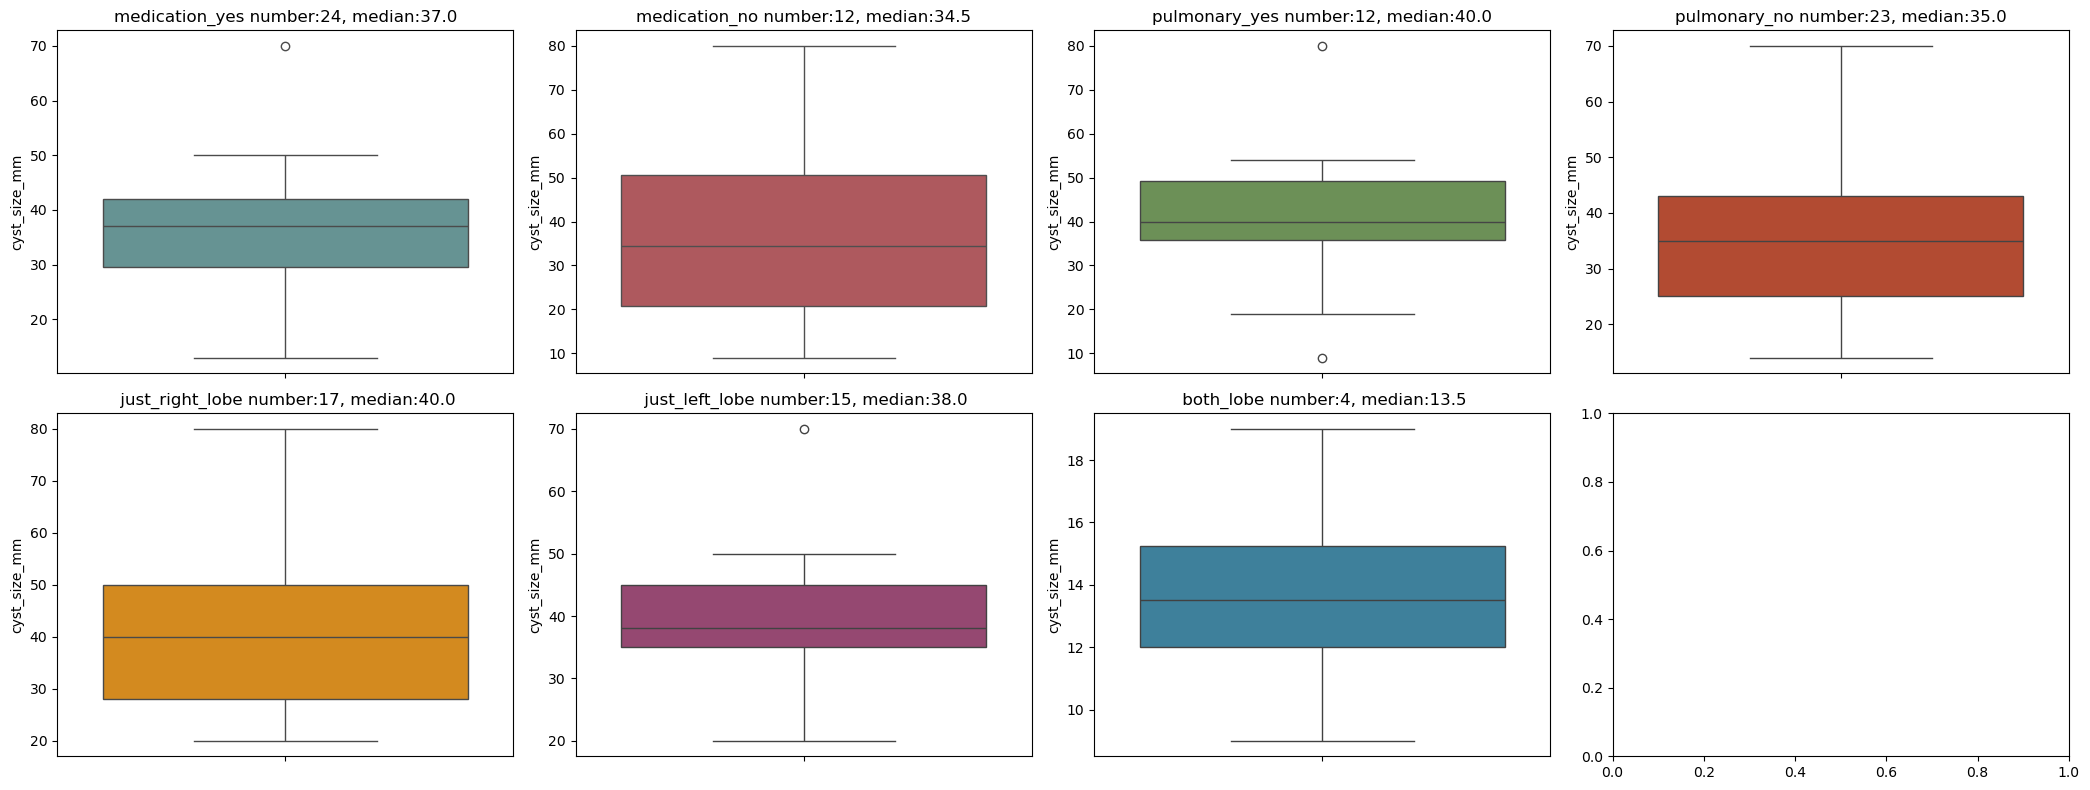

In [15]:
#drawing boxplot of binary data
fig,axes=plt.subplots(2,4,figsize=(21,8))
sns.boxplot(data=med_yes,ax=axes[0,0],color='#5E9B9B')
axes[0,0].set_title(f'medication_yes number:{len(med_yes)}, median:{med_yes.median()}')
sns.boxplot(data=med_no,ax=axes[0,1],color= '#BC4B51')
axes[0,1].set_title(f'medication_no number:{len(med_no)}, median:{med_no.median()}')
sns.boxplot(data=pulmonary_yes,ax=axes[0,2],color='#6A994E')
axes[0,2].set_title(f'pulmonary_yes number:{len(pulmonary_yes)}, median:{pulmonary_yes.median()}')
sns.boxplot(data=pulmonary_no,ax=axes[0,3],color='#C73E1D')
axes[0,3].set_title(f'pulmonary_no number:{len(pulmonary_no)}, median:{pulmonary_no.median()}')
sns.boxplot(data=just_right_lobe,ax=axes[1,0],color='#F18F01')
axes[1,0].set_title(f' just_right_lobe number:{len(just_right_lobe)}, median:{just_right_lobe.median()}')
sns.boxplot(data=just_left_lobe,ax=axes[1,1],color='#A23B72')
axes[1,1].set_title(f' just_left_lobe number:{len(just_left_lobe)}, median:{just_left_lobe.median()}')
sns.boxplot(data=both_lobe,ax=axes[1,2],color='#2E86AB')
axes[1,2].set_title(f' both_lobe number:{len(both_lobe)}, median:{both_lobe.median()}')
plt.tight_layout()
plt.show()






In [16]:
#calculate the correlation between place of thyroid involvement(left or right or both lobe) and cyst size
#we used kruskal exam
len_just_left_lobe=len(just_left_lobe)
median_just_left_lobe=just_left_lobe.median()
len_just_right_lobe=len(just_right_lobe)
median_just_right_lobe=just_right_lobe.median()
len_both_lobe=len(both_lobe)
median_both_lobe=both_lobe.median()
stat,p=kruskal(just_left_lobe,just_right_lobe,both_lobe)
print(stat,p)
#There is a significant difference in cyst size between place of thyroid lobe involvement groups 

10.430025696527805 0.005434363653893976


In [17]:
#calculate the correlation between binary variables
#(medication,has_pulmonary,has_digestive,left_lobe,right_lobe) and cyst size using Mann Whitney test
def mann_whitney_summary(df,outcome,group):
#df: dataframe , outcome:cyst_size ,group: binary groups    
    group_no=df[outcome][df[group]==0].dropna()
    group_yes=df[outcome][df[group]==1].dropna()
    n1,n2=len(group_no),len(group_yes)
    median1,median2=group_no.median(),group_yes.median()
    stat,p_value= stats.mannwhitneyu(group_yes, group_no)
    effect_size=1-2*stat/(len(group_yes)*len(group_no))
    return n1,n2,p_value,effect_size,median1,median2

ans=list()
indexes=list()
groups_name=['medication','has_pulmonary','has_digestive','left_lobe','right_lobe']
vs_group='cyst_size_mm'
for group in groups_name:
    a=mann_whitney_summary(df,vs_group,group)
    b=group+ ' vs ' + vs_group
    indexes.append(b)
    ans.append(a)
df_end1=pd.DataFrame(ans,index=indexes,columns=['count_no','count_yes','p_value','effect_size','median_no','median_yes'])
df_end1['significant']=df_end1['p_value']<0.05
df_end1.index.name='comparison'


    

In [18]:
#The table below summarizes Mann–Whitney U test results comparing cyst size across binary clinical variables.
df_end1.to_csv('thyroid_cyst_summary.csv',index=True)